# Assistant RAG sur les lois numériques du Bénin
**AI4Youth / Ed. Lomé 2026 — Catégorie : Application (RAG / LLM intégré)** — *version 2 (après première itération d'évaluation)*

## 1. Problème et objectif
Beaucoup de citoyens ignorent ce que la loi béninoise prévoit face aux problèmes numériques du quotidien. *Exemple : une personne publie ma photo sans mon consentement — que dit la loi ?* Les textes existent, mais sont longs, techniques et dispersés.

**Objectif :** un chatbot qui répond en langage simple **uniquement à partir des textes officiels** et **cite l'article exact**, ou dit clairement qu'il ne sait pas.

**Pourquoi un RAG (et pas un LLM seul ni un fine-tuning) ?** Un LLM seul hallucine des articles ; un fine-tuning est coûteux, figé dans le temps et sans traçabilité. Le RAG garde les textes à jour (on remplace un PDF), rend les réponses vérifiables (citations) et permet un refus explicite quand rien ne correspond.

## 2. Architecture
```
PDF de lois → extraction + contrôle qualité (réparation des PDF corrompus, retrait des en-têtes)
           → chunking PAR ARTICLE (+ contexte de chapitre) → embeddings bge-m3 → FAISS ┐
                                                            └→ index BM25 (mots-clés)  ┤
Question → [multi-query : reformulations au vocabulaire juridique (LLM)]                │
        → recherche hybride dense + BM25 → fusion RRF → re-ranking (cross-encoder)
        → seuil de pertinence (grading) → prompt augmenté → Gemini → réponse + articles cités
```
Choix d'intégration : le pipeline est un **module Python unique (`rag_core.py`)** réutilisé par ce notebook, par une application **Streamlit** (`app.py`) et par un **CLI**. Streamlit est justifié par sa rapidité de mise en œuvre pour une démo web ; l'accent du projet est mis sur la rigueur du pipeline et son évaluation, pas sur l'interface.

## 3. Plan du notebook
1. Installation et configuration  2. Pipeline (code commenté)  3. Choix du modèle LLM  4. Corpus, contrôle qualité et EDA  5. Indexation  6. Démonstration  7. Ingénierie de prompt  8. Évaluation (journal d'expérimentations, retrieval, seuil, génération, latence/coût)  9. Analyse, limites, éthique

## 4. Installation et configuration

In [1]:
!pip install -q sentence-transformers faiss-cpu pypdf google-genai pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 35.2 MB/s eta 0:00:00


In [2]:
import os, sys
# Clé API Gemini : secret Colab "GEMINI_API_KEY", sinon variable d'environnement, sinon saisie masquée.
if not os.getenv("GEMINI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
    except Exception:
        import getpass
        os.environ["GEMINI_API_KEY"] = getpass.getpass("Clé API Gemini : ")
print("Clé chargée :", bool(os.getenv("GEMINI_API_KEY")))

Clé API Gemini : ··········
Clé chargée : True


## 5. Le pipeline (écrit dans `rag_core.py`)
Chaque cellule ci-dessous écrit une partie du module `rag_core.py` (via `%%writefile`), puis on l'importe. Le même fichier est réutilisé par l'application et le CLI : **une seule source de vérité**.

### 5.1 Configuration et hyperparamètres
Les choix suivent les recommandations du cours (slides) : chunks de taille modérée, K entre 4 et 8, embedding multilingue. **Température basse (0,1)** : en droit on cherche la fidélité au texte, pas la créativité. `RERANK_THRESHOLD` est un seuil **calibré automatiquement** en section 8.2. Deux re-rankers sont comparés : le premier essai (`mmarcoFR`, petit modèle) et `BAAI/bge-reranker-v2-m3` (multilingue).

In [3]:
%%writefile rag_core.py
"""rag_core.py — Pipeline RAG « Lois numériques du Bénin ».

Source unique du pipeline : utilisée par le notebook, l'application Streamlit et le CLI.
Les imports lourds (torch, faiss, google-genai) sont faits à la demande.
"""
import os
import re
import json
import time
import unicodedata
from pathlib import Path

import numpy as np

CONFIG = {
    "EMBEDDING_MODEL": "BAAI/bge-m3",                                    # multilingue, bon en français
    "CROSS_ENCODER_MODEL": "BAAI/bge-reranker-v2-m3",                    # re-ranking multilingue (défaut)
    "CROSS_ENCODER_BASELINE": "antoinelouis/crossencoder-me5-small-mmarcoFR",  # 1er essai, comparé en section 10
    "LLM_MODEL": os.getenv("GEMINI_MODEL", "gemini-flash-latest"),       # modèle principal
    "LLM_FALLBACKS": ["gemini-flash-lite-latest", "gemini-3.5-flash"],   # essayés si le principal est indisponible / épuisé
    "TEMPERATURE": 0.1,       # faible : on veut de la fidélité au texte de loi, pas de créativité
    "MAX_OUTPUT_TOKENS": 2048,  # marge large (les modèles « thinking » consomment aussi ce budget)
    "DEFAULT_MODE": "hybrid_rerank",  # dense | bm25 | hybrid | hybrid_rerank (fixé d'après l'évaluation, section 10)
    "K_CANDIDATES": 20,       # candidats récupérés avant fusion / re-ranking
    "K_FINAL": 4,             # extraits envoyés au LLM
    "RERANK_THRESHOLD": 0.05,  # seuil de pertinence (à CALIBRER, cf. notebook)
    "RRF_K": 60,              # constante de Reciprocal Rank Fusion
    "N_QUERY_VARIANTS": 3,    # reformulations générées en multi-query
}
LLM_LOG = []  # une entrée par appel LLM : latence, tokens (sert à l'analyse coût / latence)

Writing rag_core.py


### 5.2 Chargement du corpus et contrôle qualité
Extraction du texte de chaque PDF, puis trois traitements issus de la **première itération** (voir le journal en section 8.0) :
1. **Réparation des lignes corrompues** : certains PDF (ex. celui de l'APDP) utilisent une police sans table Unicode ; le texte sort alors décalé (« DXUD SDU OH ELDLV » pour « aura par le biais »). Une réparation *heuristique* (décalage de glyphes) est appliquée et chiffrée dans `CORPUS_REPORT`. **Elle ne remplace pas une copie propre du PDF.**
2. **Suppression des en-têtes / pieds de page répétés** (ex. « LOI N°2017-20 DU 20 AVRIL 2018 PORTANT CODE… »), qui polluaient les chunks.
3. **Indicateurs de qualité** : part de mots français courants (~0,3 attendu) et caractères de contrôle (0 attendu).

In [4]:
%%writefile -a rag_core.py
from collections import Counter

CORPUS_REPORT = {}  # rapport de qualité d'extraction, rempli par load_corpus()

_COMMON = frozenset("de la le les des du et en un une que qui est dans pour par sur au aux ou ne pas plus se sa son ses "
                    "ce cette il elle a à l d".split())


def text_quality(text):
    """Indicateurs d'une extraction saine : part de mots français courants (~0,3 attendu) et caractères de contrôle (0 attendu)."""
    words = re.findall(r"[A-Za-zÀ-ÿ]+", text)
    ctrl = sum(1 for ch in text if ord(ch) < 32 and ch not in "\n\r\t")
    common = sum(w.lower() in _COMMON for w in words) / len(words) if words else 0.0
    return {"mots_courants": round(common, 3), "car_controle": ctrl}


def _decode_segment(seg):
    """Décode un segment dont les glyphes sont décalés (police sans table Unicode) : code réel = code lu + 29 (ASCII),
    + 62 pour les lettres accentuées ; U+0335 = apostrophe. Heuristique vérifiée sur des exemples réels du PDF de l'APDP."""
    if seg.isdigit():
        return seg
    if not any(ch.isalpha() for ch in seg) and all(ord(ch) >= 32 for ch in seg):
        return seg  # ponctuation imprimable authentique (« : », « , »…) : les glyphes corrompus sont des codes de contrôle
    lower = sum(ch.islower() and ch.isascii() for ch in seg)
    if lower and lower / len(seg) >= 0.4:
        return seg  # segment majoritairement normal : on n'y touche pas
    out = []
    for ch in seg:
        o = ord(ch)
        if ch.islower() and ch.isascii():
            out.append(ch)
        elif o == 0x335:
            out.append("’")
        elif 3 <= o <= 97:
            out.append(chr(o + 29))
        elif 160 <= o <= 200:
            out.append(chr(o + 62))
        else:
            out.append(ch)
    return "".join(out)


def repair_shifted_text(text):
    """Répare les lignes corrompues (repérées par le glyphe \\x03 = espace décalé). Retourne (texte, nb_lignes_réparées)."""
    out, n = [], 0
    for line in text.split("\n"):
        if "\x03" not in line:
            out.append(line)
            continue
        n += 1
        pieces = re.split(r"([ \x03]+)", line)
        out.append("".join(" " if ("\x03" in pc) else (pc if re.fullmatch(r"[ \t]+", pc) else _decode_segment(pc)) for pc in pieces))
    return "\n".join(out), n


def _drop_running_lines(text, min_count=30, min_len=25):
    """Supprime les en-têtes / pieds de page répétés (ex. « [546] LOI N°2017-20 DU 20 AVRIL 2018 PORTANT CODE… »)."""
    norm = lambda l: re.sub(r"\d+", "#", re.sub(r"\s+", " ", l.strip()))
    lines = text.split("\n")
    cnt = Counter(norm(l) for l in lines if l.strip())
    bad = {k for k, v in cnt.items() if v >= min_count and len(k) >= min_len and not k.lower().startswith("article")}
    kept = [l for l in lines if norm(l) not in bad]
    return "\n".join(kept), len(lines) - len(kept)


def _clean(text):
    """Nettoyage léger du texte extrait des PDF."""
    text = text.replace("\r", "")
    text = re.sub(r"-\n(?=[a-zà-ÿ])", "", text)  # mots coupés en fin de ligne
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def load_corpus(folder="corpus"):
    """Charge tous les .pdf / .txt / .md du dossier. Retourne {nom_du_fichier_sans_extension: texte}.
    Répare l'extraction corrompue, retire les en-têtes répétés, et remplit CORPUS_REPORT (contrôle qualité)."""
    laws = {}
    for p in sorted(Path(folder).iterdir()):
        suffix = p.suffix.lower()
        if suffix == ".pdf":
            from pypdf import PdfReader
            reader = PdfReader(str(p))
            text = "\n".join((pg.extract_text() or "") for pg in reader.pages)
        elif suffix in (".txt", ".md"):
            text = p.read_text(encoding="utf-8")
        else:
            continue
        text, n_rep = repair_shifted_text(text)
        text, n_drop = _drop_running_lines(text)
        text = _clean(text)
        laws[p.stem] = text
        CORPUS_REPORT[p.stem] = {"caracteres": len(text), "lignes_reparees": n_rep,
                                 "lignes_repetitives_supprimees": n_drop, **text_quality(text)}
    return laws

Appending to rag_core.py


### 5.3 Chunking : par article (stratégie proposée) vs taille fixe (baseline)
Un texte de loi est structuré en **articles**, unités de sens autonomes et citables. Découper par article (1) garde un sens complet dans chaque chunk, (2) permet de **citer précisément** « Loi X, Article N », (3) évite de couper une règle en deux. Les **titres de structure** (LIVRE / TITRE / CHAPITRE / SECTION) sont retirés du corps de l'article précédent, où le PDF les plaçait, et conservés comme **contexte** des articles suivants (ex. « CHAPITRE X — DES INFRACTIONS DE DROIT COMMUN COMMISES EN LIGNE »). La stratégie *taille fixe* sert de **baseline**.

In [5]:
%%writefile -a rag_core.py
# En-tête d'article : « Article 12 », « Article premier », « Art. 5 bis » ... en début de ligne.
# ADAPTEZ cette regex au format réel de vos PDF si peu d'articles sont détectés.
ARTICLE_RE = re.compile(
    r"(?m)^[ \t]*(?:Article|ARTICLE|Art\.)[ \t]+(?P<num>premier|1er|\d+)(?P<suf>[ \t]*(?:bis|ter|quater))?\b[^\n]*"
)


def _norm_num(num, suf):
    n = "1" if num.lower() in ("premier", "1er") else num
    return n + (suf.strip().lower() if suf else "")


def _split_long(text, size, overlap):
    """Découpe un texte trop long en morceaux de ~size caractères avec recouvrement."""
    if len(text) <= size:
        return [text]
    parts, start = [], 0
    while start < len(text):
        end = min(start + size, len(text))
        if end < len(text):
            cut = text.rfind("\n", start + size // 2, end)
            if cut == -1:
                cut = text.rfind(" ", start + size // 2, end)
            if cut != -1:
                end = cut
        parts.append(text[start:end].strip())
        if end >= len(text):
            break
        start = max(end - overlap, start + 1)
    return parts


# Titres de structure (LIVRE / TITRE / CHAPITRE / SECTION…) : ils figurent à la fin du texte de l'article précédent
# dans le PDF ; on les retire du corps de l'article et on les réutilise comme CONTEXTE des articles qui suivent.
HEADING_RE = re.compile(r"(?m)^[ \t]*(?:LIVRE|TITRE|CHAPITRE|SECTION|SOUS-SECTION|PARTIE)\b.*$")


def chunk_by_article(law, text, max_chars=2500, overlap=250):
    """Stratégie A (proposée) : 1 chunk = 1 article de loi, avec métadonnées (loi, n° d'article) et contexte de structure."""
    matches = list(ARTICLE_RE.finditer(text))
    chunks, ctx = [], ""
    for i, m in enumerate(matches):
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        body = text[m.start():end].strip()
        h = HEADING_RE.search(body)
        next_ctx = ctx
        if h:
            next_ctx = re.sub(r"\s+", " ", body[h.start():]).strip()[:300]
            body = body[:h.start()].rstrip()
        art = _norm_num(m.group("num"), m.group("suf"))
        meta = {"loi": law, "article": art, "strategy": "article"}
        for j, part in enumerate(_split_long(body, max_chars, overlap)):
            txt = part if j == 0 else f"Article {art} (suite)\n{part}"
            chunks.append({"text": txt, "meta": dict(meta), "ctx": ctx})
        ctx = next_ctx
    return chunks


def chunk_fixed(law, text, size=1500, overlap=300):
    """Stratégie B (baseline) : découpage en fenêtres de taille fixe, sans tenir compte des articles."""
    return [
        {"text": p, "meta": {"loi": law, "article": None, "strategy": "fixed"}}
        for p in _split_long(text, size, overlap)
    ]


def build_chunks(laws, strategy="article"):
    fn = chunk_by_article if strategy == "article" else chunk_fixed
    out = []
    for law, text in laws.items():
        out.extend(fn(law, text))
    return out

Appending to rag_core.py


### 5.4 Indexation : vecteurs (FAISS) + mots-clés (BM25)
- **Embeddings** `BAAI/bge-m3` (multilingue) + **FAISS** : recherche par sens (cosinus). Le texte indexé = contexte de chapitre + article.
- **BM25** : recherche lexicale, précieuse en droit où les termes exacts comptent.
Les deux sont combinés ensuite (recherche hybride).

In [6]:
%%writefile -a rag_core.py
STOPWORDS = set(
    "le la les de du des un une et en a au aux ce ces que qui quoi dans par pour sur avec est sont l d j n s c qu "
    "il elle ils elles on se sa son ses leur leurs ou ne pas plus ni mais donc car y".split()
)


def tokenize(text):
    """Minuscules, sans accents, sans mots vides : sert à la recherche lexicale BM25."""
    text = unicodedata.normalize("NFD", text.lower())
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return [t for t in re.findall(r"[a-z0-9]+", text) if t not in STOPWORDS and len(t) > 1]


class BM25:
    """BM25 Okapi minimal (recherche par mots-clés)."""

    def __init__(self, docs, k1=1.5, b=0.75):
        self.k1, self.b, self.N = k1, b, len(docs)
        self.dl = [len(d) for d in docs]
        self.avgdl = sum(self.dl) / max(self.N, 1)
        self.inverted, df = {}, {}
        for i, d in enumerate(docs):
            counts = {}
            for t in d:
                counts[t] = counts.get(t, 0) + 1
            for t, f in counts.items():
                self.inverted.setdefault(t, []).append((i, f))
                df[t] = df.get(t, 0) + 1
        self.idf = {t: float(np.log(1 + (self.N - n + 0.5) / (n + 0.5))) for t, n in df.items()}

    def scores(self, query_tokens):
        s = np.zeros(self.N)
        for t in set(query_tokens):
            for i, f in self.inverted.get(t, []):
                denom = f + self.k1 * (1 - self.b + self.b * self.dl[i] / self.avgdl)
                s[i] += self.idf[t] * f * (self.k1 + 1) / denom
        return s


_EMB, _CE = None, {}


def get_embedder():
    global _EMB
    if _EMB is None:
        from sentence_transformers import SentenceTransformer
        _EMB = SentenceTransformer(CONFIG["EMBEDDING_MODEL"])
    return _EMB


def get_cross_encoder(name=None):
    name = name or CONFIG["CROSS_ENCODER_MODEL"]
    if name not in _CE:
        from sentence_transformers import CrossEncoder
        _CE[name] = CrossEncoder(name, max_length=512)
    return _CE[name]


def search_text(chunk):
    """Texte indexé (embeddings + BM25) : contexte de structure (chapitre / section) + texte de l'article."""
    return (chunk.get("ctx", "") + "\n" + chunk["text"]).strip()


class Index:
    """Vector store FAISS (recherche sémantique) + index BM25 (recherche lexicale) sur les mêmes chunks."""

    def __init__(self, chunks, embeddings=None):
        import faiss
        self.chunks = chunks
        if embeddings is None:
            embeddings = get_embedder().encode(
                [search_text(c) for c in chunks], normalize_embeddings=True, batch_size=16, show_progress_bar=True
            )
        self.emb = np.asarray(embeddings, dtype="float32")
        self.faiss = faiss.IndexFlatIP(self.emb.shape[1])  # produit scalaire = cosinus (vecteurs normalisés)
        self.faiss.add(self.emb)
        self.bm25 = BM25([tokenize(search_text(c)) for c in chunks])

    def save(self, folder="index"):
        Path(folder).mkdir(exist_ok=True)
        np.save(Path(folder) / "embeddings.npy", self.emb)
        (Path(folder) / "chunks.json").write_text(json.dumps(self.chunks, ensure_ascii=False), encoding="utf-8")

    @classmethod
    def load(cls, folder="index"):
        chunks = json.loads((Path(folder) / "chunks.json").read_text(encoding="utf-8"))
        return cls(chunks, embeddings=np.load(Path(folder) / "embeddings.npy"))

Appending to rag_core.py


### 5.5 Recherche : dense, BM25, hybride (RRF), re-ranking
La fusion **RRF** combine les classements dense et BM25 sans avoir à normaliser leurs scores. Le **cross-encoder** ré-ordonne ensuite les candidats en lisant conjointement la question et chaque extrait (plus précis en principe, mais plus lent). Son apport est **mesuré**, pas supposé (section 8.1).

In [7]:
%%writefile -a rag_core.py
def dense_search(idx, query, k):
    qv = get_embedder().encode([query], normalize_embeddings=True).astype("float32")
    _, ids = idx.faiss.search(qv, k)
    return [int(i) for i in ids[0] if i >= 0]


def bm25_search(idx, query, k):
    s = idx.bm25.scores(tokenize(query))
    return [int(i) for i in np.argsort(-s)[:k] if s[i] > 0]


def rrf(rankings, top=None, k_const=None):
    """Reciprocal Rank Fusion : fusionne plusieurs classements (score = somme de 1/(k+rang))."""
    k_const = k_const or CONFIG["RRF_K"]
    scores = {}
    for ranking in rankings:
        for rank, i in enumerate(ranking):
            scores[i] = scores.get(i, 0.0) + 1.0 / (k_const + rank + 1)
    order = sorted(scores, key=scores.get, reverse=True)
    return order[:top] if top else order


def hybrid_search(idx, query, k):
    return rrf([dense_search(idx, query, k), bm25_search(idx, query, k)], top=k)


def rerank(idx, query, ids, top, model=None):
    """Re-ranking par cross-encoder : score chaque couple (question, extrait). Retourne [(id, score)]."""
    if not ids:
        return []
    scores = get_cross_encoder(model).predict([(query, idx.chunks[i]["text"]) for i in ids])
    ranked = sorted(zip(ids, scores), key=lambda x: -x[1])
    return [(i, float(s)) for i, s in ranked[:top]]


def retrieve(idx, question, mode="hybrid_rerank", k=None, variants=None, reranker=None):
    """mode ∈ {dense, bm25, hybrid, hybrid_rerank}. `variants` = reformulations (multi-query).
    Retourne une liste de (id_chunk, score_rerank_ou_None), meilleur en premier."""
    k = k or CONFIG["K_FINAL"]
    kc = CONFIG["K_CANDIDATES"]
    queries = [question] + list(variants or [])
    if mode == "dense":
        rankings = [dense_search(idx, q, kc) for q in queries]
    elif mode == "bm25":
        rankings = [bm25_search(idx, q, kc) for q in queries]
    else:
        rankings = [hybrid_search(idx, q, kc) for q in queries]
    fused = rrf(rankings, top=kc)
    if mode == "hybrid_rerank":
        return rerank(idx, question, fused, k, model=reranker)
    return [(i, None) for i in fused[:k]]

Appending to rag_core.py


### 5.6 LLM : prompt système, appels Gemini robustes, multi-query
- **Prompt système** : rôle, règle « contexte uniquement », format de citation, refus explicite, structure de réponse, avertissement.
- **Robustesse (issue de la 1re itération : modèle retiré en 404, surcharges 503, quota journalier de 20 requêtes)** : cache disque ; bascule automatique vers des modèles de secours (`LLM_FALLBACKS`) ; un modèle au quota journalier épuisé ou introuvable est écarté ; attente adaptée pour les erreurs temporaires ; `QuotaExceeded` si plus aucun modèle n'est utilisable.
- **Multi-query** : la question citoyenne (« on a pris ma photo ») est reformulée pour imiter la formulation des articles de loi (« porter atteinte à l'intimité de la vie privée », « sans le consentement de »…).

In [8]:
%%writefile -a rag_core.py
import hashlib

SYSTEM_PROMPT = """Tu es un assistant d'information juridique spécialisé dans le droit du numérique en République du Bénin.

RÈGLES :
1. Réponds UNIQUEMENT à partir des extraits de textes fournis dans le CONTEXTE. N'utilise aucune autre connaissance juridique.
2. Cite la source de chaque règle avec le format [Loi, Article N].
3. Si le contexte ne permet pas de répondre, réponds : « Je ne trouve pas de disposition correspondante dans les textes dont je dispose. » N'invente JAMAIS d'article, de sanction ou de procédure.
4. Structure ta réponse : **Ce que dit la loi** ; **Sanctions ou recours** (uniquement s'ils figurent dans le contexte) ; **Limites** (ce que les extraits ne permettent pas de conclure).
5. Utilise un langage simple, accessible à un non-juriste.
6. Termine par : « Information générale, qui ne remplace pas l'avis d'un avocat ou d'un professionnel du droit. »"""

REFUSAL = (
    "Je ne trouve pas de disposition correspondante dans les textes dont je dispose. "
    "Essayez de reformuler votre question ou consultez un professionnel du droit."
)


class QuotaExceeded(RuntimeError):
    """Plus aucun modèle utilisable (quota journalier épuisé ou modèles indisponibles)."""


CACHE_DIR = Path("llm_cache")  # cache disque : une requête identique ne consomme pas de quota deux fois
USE_CACHE = True
_CLIENT = None
_DEAD_MODELS = {}  # modèle -> raison (quota journalier épuisé / 404) pour la session en cours


def reset_dead_models():
    _DEAD_MODELS.clear()


def get_client():
    global _CLIENT
    if _CLIENT is None:
        key = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
        if not key:
            raise RuntimeError("Clé API absente : définissez la variable d'environnement GEMINI_API_KEY.")
        from google import genai
        _CLIENT = genai.Client(api_key=key)
    return _CLIENT


def list_models():
    """Modèles disponibles pour votre clé (n'utilise pas de quota de génération)."""
    return [m.name.replace("models/", "") for m in get_client().models.list()
            if "generateContent" in (m.supported_actions or [])]


def _retry_delay(msg):
    m = re.search(r"retry in ([\d.]+)s", msg) or re.search(r"retryDelay['\"]?: ?['\"]?(\d+)", msg)
    return float(m.group(1)) if m else None


def call_llm(prompt, system=None, kind="generation", temperature=None, max_tokens=None, retries=4):
    """Appel Gemini : cache disque, bascule automatique entre modèles, retry adapté à l'erreur, mesure latence / tokens.
    - quota JOURNALIER ou modèle introuvable (404) : ce modèle est écarté, on passe au suivant (LLM_FALLBACKS) ;
    - 503 / 429 « par minute » : on essaie le modèle suivant, puis on attend avant de recommencer ;
    - 400/401/403 : erreur de configuration (clé…), non réessayable ;
    - si tous les modèles sont écartés : QuotaExceeded."""
    temp = CONFIG["TEMPERATURE"] if temperature is None else temperature
    mx = max_tokens or CONFIG["MAX_OUTPUT_TOKENS"]
    ckey = hashlib.sha256(json.dumps([CONFIG["LLM_MODEL"], system, prompt, temp, mx], ensure_ascii=False).encode()).hexdigest()
    cfile = CACHE_DIR / f"{ckey}.json"
    if USE_CACHE and cfile.exists():
        rec = json.loads(cfile.read_text(encoding="utf-8"))
        LLM_LOG.append({**rec["stats"], "kind": kind, "attempt": 0, "cached": True})  # mesures d'origine conservées
        return rec["text"]

    from google.genai import types
    cfg = types.GenerateContentConfig(system_instruction=system, temperature=temp, max_output_tokens=mx)
    models = [CONFIG["LLM_MODEL"]] + [m for m in CONFIG.get("LLM_FALLBACKS", []) if m != CONFIG["LLM_MODEL"]]
    last_err = None
    for attempt in range(retries):
        alive = [m for m in models if m not in _DEAD_MODELS]
        if not alive:
            raise QuotaExceeded("Aucun modèle utilisable : " + " ; ".join(f"{m} ({r})" for m, r in _DEAD_MODELS.items()))
        wait = 0.0
        for model in alive:
            try:
                t0 = time.time()
                r = get_client().models.generate_content(model=model, contents=prompt, config=cfg)
                u = getattr(r, "usage_metadata", None)
                stats = {
                    "latency_s": time.time() - t0, "model": model,
                    "tokens_in": getattr(u, "prompt_token_count", 0) or 0,
                    "tokens_out": getattr(u, "candidates_token_count", 0) or 0,
                }
                LLM_LOG.append({**stats, "kind": kind, "attempt": attempt + 1, "cached": False})
                text = r.text or ""
                if USE_CACHE and text:
                    CACHE_DIR.mkdir(exist_ok=True)
                    cfile.write_text(json.dumps({"text": text, "stats": stats}, ensure_ascii=False), encoding="utf-8")
                return text
            except Exception as e:
                msg, code, last_err = str(e), getattr(e, "code", None), e
                if "PerDay" in msg:
                    _DEAD_MODELS[model] = "quota journalier épuisé"
                elif code == 404:
                    _DEAD_MODELS[model] = "modèle indisponible (404)"
                elif code in (400, 401, 403):
                    raise RuntimeError(f"Erreur de configuration (non réessayable) : {msg[:300]}") from e
                elif code == 429 or "RESOURCE_EXHAUSTED" in msg:
                    wait = max(wait, (_retry_delay(msg) or 10) + 1)
                else:  # 503 surcharge, réseau…
                    wait = max(wait, 2 ** attempt * 2)
        if wait:
            time.sleep(min(wait, 65))
    raise RuntimeError(f"Échec de l'appel LLM après {retries} tentatives : {last_err}")


def expand_query(question, n=None):
    """Multi-query : reformule la question pour imiter la FORMULATION des articles de loi.
    Écart de vocabulaire fréquent : le citoyen dit « photo / publier / Facebook », la loi dit
    « image », « porter atteinte à l'intimité de la vie privée », « sans le consentement de »."""
    n = n or CONFIG["N_QUERY_VARIANTS"]
    prompt = (
        f"Un citoyen pose cette question sur le droit du numérique au Bénin :\n« {question} »\n\n"
        f"Écris {n} requêtes de recherche, une par ligne, sans numérotation ni commentaire. Chacune doit imiter "
        "la formulation d'un article de code pénal ou de code du numérique francophone (vocabulaire juridique exact : "
        "« porter atteinte à », « sans le consentement de », « est puni de », « le fait de », notions d'infraction, "
        "de sanction, de données à caractère personnel, de vie privée, de système informatique…). "
        "Varie les angles : (1) l'infraction pénale possible, (2) la protection des données personnelles, "
        "(3) la sanction ou le recours."
    )
    try:
        text = call_llm(prompt, kind="query_expansion", temperature=0.3, max_tokens=512)
    except QuotaExceeded:
        raise
    except RuntimeError:
        return []
    lines = [re.sub(r"^[\s\-\*\d\.\)]+", "", ln).strip() for ln in text.splitlines()]
    return [ln for ln in lines if ln][:n]

Appending to rag_core.py


### 5.7 Fonctions `select_sources()` et `answer()` : le pipeline de bout en bout
`select_sources` = reformulation → recherche → **seuil de pertinence** (sans appeler de génération, donc sans quota) ; `answer` ajoute le prompt augmenté et la génération. Si aucun extrait n'atteint le seuil, le système **refuse de répondre** sans appeler le LLM.

In [9]:
%%writefile -a rag_core.py
def _label(meta):
    return f"{meta['loi']}, Article {meta['article']}" if meta.get("article") else f"{meta['loi']}, extrait"


def select_sources(idx, question, mode=None, multiquery=True, reranker=None):
    """Étapes SANS génération : (multi-query) → retrieval → seuil de pertinence.
    Retourne (reformulations, sources). Utilisable pour l'évaluation sans consommer de quota de génération."""
    mode = mode or CONFIG["DEFAULT_MODE"]
    variants = expand_query(question) if multiquery else []
    hits = retrieve(idx, question, mode, variants=variants, reranker=reranker)
    thr = CONFIG["RERANK_THRESHOLD"]
    if mode == "hybrid_rerank" and thr is not None:
        hits = [(i, s) for i, s in hits if s >= thr]  # document grading : on écarte le hors-sujet
    sources = [
        {"label": _label(idx.chunks[i]["meta"]), "loi": idx.chunks[i]["meta"]["loi"],
         "article": idx.chunks[i]["meta"].get("article"), "score": s, "text": idx.chunks[i]["text"]}
        for i, s in hits
    ]
    return variants, sources


def answer(idx, question, mode=None, multiquery=True, reranker=None):
    """Pipeline complet : sélection des sources → prompt augmenté → génération."""
    t0, log_start = time.time(), len(LLM_LOG)
    out = {"question": question, "variants": [], "sources": [], "refused": False, "error": None}
    try:
        out["variants"], out["sources"] = select_sources(idx, question, mode, multiquery, reranker)
        if not out["sources"]:
            out.update(answer=REFUSAL, refused=True)
        else:
            context = "\n\n---\n\n".join(f"[{s['label']}]\n{s['text']}" for s in out["sources"])
            prompt = f"CONTEXTE :\n{context}\n\nQUESTION : {question}\n\nRÉPONSE :"
            out["answer"] = call_llm(prompt, system=SYSTEM_PROMPT, kind="generation")
    except QuotaExceeded as e:
        out.update(answer="Quota de l'API épuisé pour le moment. Réessayez plus tard.", error=str(e))
    except RuntimeError as e:
        out.update(answer="Le service de génération est momentanément indisponible. Réessayez plus tard.",
                   error=str(e))
    out["latency_s"] = time.time() - t0
    out["llm_calls"] = LLM_LOG[log_start:]
    return out

if __name__ == "__main__":
    import sys
    q = " ".join(sys.argv[1:]) or input("Question : ")
    result = answer(Index.load("index"), q)
    print("\n" + result["answer"])
    print("\nSources :")
    for s in result["sources"]:
        print(f" - {s['label']} (score {s['score']})")
    print(f"\nLatence : {result['latency_s']:.1f}s")

Appending to rag_core.py


In [10]:
from rag_core import *
import rag_core
import re, json, time
import pandas as pd
import matplotlib.pyplot as plt

## 6. Choix du modèle LLM
Les noms de modèles changent vite (un modèle par défaut a été retiré en cours de projet : erreur 404). On **liste les modèles disponibles pour la clé** (opération sans quota de génération) et on fixe le modèle principal ; les secours sont dans `CONFIG["LLM_FALLBACKS"]`.

In [11]:
available = list_models()
print([m for m in available if "flash" in m and "tts" not in m and "image" not in m])
CONFIG["LLM_MODEL"] = "gemini-flash-latest"            # ← modèle principal (à adapter si absent de la liste ci-dessus)
CONFIG["LLM_FALLBACKS"] = ["gemini-flash-lite-latest", "gemini-3.5-flash"]
print("Principal :", CONFIG["LLM_MODEL"], "| secours :", CONFIG["LLM_FALLBACKS"])

['gemini-2.5-flash', 'gemini-flash-latest', 'gemini-flash-lite-latest', 'gemini-2.5-flash-lite', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite-preview', 'gemini-3.1-flash-lite', 'gemini-3.5-flash', 'gemini-3.5-flash-lite', 'gemini-omni-flash-preview', 'gemini-omni-1.1-flash', 'gemini-3.6-flash', 'gemini-3.7-flash', 'gemini-3.8-flash']
Principal : gemini-flash-latest | secours : ['gemini-flash-lite-latest', 'gemini-3.5-flash']


## 7. Corpus, contrôle qualité et analyse exploratoire (EDA)
Textes utilisés (à reporter dans le README) : **Loi n° 2017-20 du 20 avril 2018 portant Code du numérique** et **Loi n° 2018-16 portant Code pénal** (PDF publics). Le Code du numérique a été **modifié par la loi n° 2020-35** (non incluse : limite à documenter).

Le nom de chaque fichier (sans extension) devient le nom de la loi dans les citations : **ne le changez pas** (il sert aussi au jeu de test).

In [12]:
from pathlib import Path
import urllib.request, shutil
Path("corpus").mkdir(exist_ok=True)

# Plusieurs sources possibles par texte, essayées dans l'ordre : on garde la première dont le texte est sain.
CORPUS_URLS = {
    "CODE-DU-NUMERIQUE.pdf": [
        "https://database.cyberpolicyportal.org/api/files/1663679910216euq2m15qn6f.pdf",
        "https://apiprod.apdp.bj/storage/f62c427c3ce1321017334e116d297abe/CODE-DU-NUMERIQUE.pdf",  # texte corrompu (réparé par heuristique)
    ],
    "le-nouveau-code-penal-2018.pdf": ["https://assemblee-nationale.bj/wp-content/uploads/2020/03/le-nouveau-code-penal-2018.pdf"],
}
FORCE_REDOWNLOAD = False   # ← True pour remplacer les PDF déjà présents (ex. pour abandonner une copie corrompue)

def sample_quality(path, pages=15):
    from pypdf import PdfReader
    r = PdfReader(str(path))
    txt = "\n".join((pg.extract_text() or "") for pg in r.pages[:pages])
    return text_quality(repair_shifted_text(txt)[0])

def fetch(url, dest):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=60) as resp, open(dest, "wb") as f:
        shutil.copyfileobj(resp, f)

for fname, urls in CORPUS_URLS.items():
    dest = Path("corpus", fname)
    if dest.exists() and not FORCE_REDOWNLOAD:
        continue
    kept = None
    for url in urls:
        tmp = Path("corpus", "_tmp_" + fname)
        try:
            fetch(url, tmp)
            q = sample_quality(tmp)
            print(f"{fname} <- {url[:60]}… qualité {q}")
            if q["mots_courants"] >= 0.25:          # texte sain : on s'arrête
                tmp.replace(dest); kept = True; break
            if kept is None:
                tmp.replace(Path("corpus", "_fallback_" + fname)); kept = False   # copie médiocre gardée en dernier recours
        except Exception as e:
            print("Échec", url[:60], ":", e)
        tmp.unlink(missing_ok=True)
    if not dest.exists() and Path("corpus", "_fallback_" + fname).exists():
        Path("corpus", "_fallback_" + fname).replace(dest)
for p in Path("corpus").glob("_fallback_*"): p.unlink()

# Dernier recours : copie sur Drive, puis envoi manuel
missing = [f for f in CORPUS_URLS if not Path("corpus", f).exists()]
if missing and "google.colab" in sys.modules:
    drive_dir = Path("/content/drive/MyDrive/rag_lois_corpus")
    for f in missing:
        if (drive_dir / f).exists():
            shutil.copy(drive_dir / f, Path("corpus", f))
    missing = [f for f in CORPUS_URLS if not Path("corpus", f).exists()]
if missing and "google.colab" in sys.modules:
    print("Fichiers manquants, envoyez-les (en gardant exactement ces noms) :", missing)
    from google.colab import files
    for name, content in files.upload().items():
        Path("corpus", name).write_bytes(content)
print(sorted(p.name for p in Path("corpus").glob("*.pdf")))

CODE-DU-NUMERIQUE.pdf <- https://database.cyberpolicyportal.org/api/files/16636799102… qualité {'mots_courants': 0.408, 'car_controle': 0}
le-nouveau-code-penal-2018.pdf <- https://assemblee-nationale.bj/wp-content/uploads/2020/03/le… qualité {'mots_courants': 0.434, 'car_controle': 0}
['CODE-DU-NUMERIQUE.pdf', 'le-nouveau-code-penal-2018.pdf']


In [13]:
laws = load_corpus("corpus")
assert laws, "Aucun texte chargé : vérifiez le dossier corpus/"
rep = pd.DataFrame(CORPUS_REPORT).T
rep["articles_detectes"] = [len(ARTICLE_RE.findall(laws[k])) for k in rep.index]
display(rep)
for name, r in CORPUS_REPORT.items():
    if r["mots_courants"] < 0.25 or r["car_controle"] > 20:
        print(f"⚠ {name} : extraction suspecte (mots courants={r['mots_courants']}, caractères de contrôle={r['car_controle']}) "
              "→ utilisez une copie propre du PDF.")
    if r["lignes_reparees"] > 0:
        print(f"ℹ {name} : {r['lignes_reparees']} lignes corrompues réparées par heuristique (voir section 5.2).")

,caracteres,lignes_reparees,lignes_repetitives_supprimees,mots_courants,car_controle,articles_detectes
CODE-DU-NUMERIQUE,599908.0,0.0,0.0,0.431,0.0,644
le-nouveau-code-penal-2018,594279.0,0.0,0.0,0.420,0.0,1004


              count    mean    std    min     25%     50%     75%     max
strategie                                                                
article      1705.0   698.0  544.0   50.0   336.0   519.0   866.0  2512.0
taille fixe  1034.0  1453.0   34.0  926.0  1431.0  1458.0  1478.0  1498.0
Doublons exacts (article) : 0
Chunks < 80 caractères (article) : 5
Chunks avec contexte de chapitre : 1675 / 1705


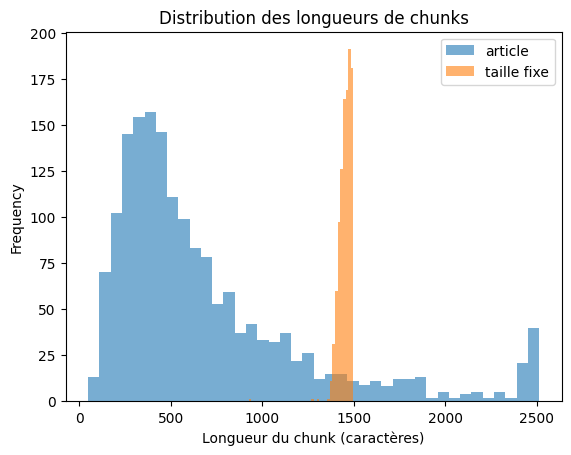

In [14]:
chunks_article = build_chunks(laws, "article")
chunks_fixed = build_chunks(laws, "fixed")
df = pd.DataFrame(
    [{"strategie": "article", "loi": c["meta"]["loi"], "n_chars": len(c["text"])} for c in chunks_article] +
    [{"strategie": "taille fixe", "loi": c["meta"]["loi"], "n_chars": len(c["text"])} for c in chunks_fixed])
print(df.groupby("strategie")["n_chars"].describe().round(0))
texts = [c["text"] for c in chunks_article]
print("Doublons exacts (article) :", len(texts) - len(set(texts)))
print("Chunks < 80 caractères (article) :", sum(len(t) < 80 for t in texts))
print("Chunks avec contexte de chapitre :", sum(bool(c.get("ctx")) for c in chunks_article), "/", len(chunks_article))
df.groupby("strategie")["n_chars"].plot(kind="hist", bins=40, alpha=0.6, legend=True)
plt.xlabel("Longueur du chunk (caractères)"); plt.title("Distribution des longueurs de chunks"); plt.show()

###  Synthèse des Observations (Chunking & Qualité d'Extraction)

####  Analyse Quantitative et Volumétrie
* **Nombre de chunks générés** : **1 705 chunks** pour la stratégie par article contre **1 034 chunks** pour la stratégie à taille fixe.
* **Distribution des longueurs** :
  * La stratégie **taille fixe** montre un profil ultra-concentré (pic orange très serré sur le graphique) avec une médiane à **1 458 caractères** et un écart-type de seulement **34 caractères**.
  * La stratégie **par article** (courbe bleue) épouse la structure naturelle de la loi. Elle affiche une moyenne de **698 caractères** et une dispersion beaucoup plus étalée (écart-type de 544).

####  Contrôle Qualité & Métriques d'Extraction
* **Doublons exacts (stratégie article)** : **0**. L'intégrité de l'extraction est parfaite, évitant toute redondance inutile dans la base de connaissances.
* **Articles très courts (< 80 caractères)** : **5 chunks**. Ces fragments ultra-courts représentent des articles de transition ou de simples renvois législatifs (ex : l'abrogation de droits exclusifs ou des articles de clôture).
* **Articles très longs (max à 2 512 caractères)** : Visible via le petit pic isolé tout à droite du graphique bleu. Ce profil correspond aux articles denses contenant de nombreuses énumérations de définitions (en particulier **l'Article 1er du Code du Numérique**, qui liste tous les termes clés comme *Abonné*, *Accès*, *APDP*, etc.).
* **Contexte de chapitre disponible** : **1 675 / 1 705 chunks** (soit **98,2 %**) intègrent avec succès leur contexte hiérarchique supérieur, ce qui garantit une excellente transmission sémantique pour le futur système RAG.
* **Qualité du formatage textuel** : L'extraction brute des PDF du corpus (Code du Numérique de 647 articles et Nouveau Code Pénal de 2018) a nécessité la réparation de lignes brisées et le traitement de scories d'encodage (ex : les résidus textuels du type `ĕ` ou `RS«UDWHXU` issus du parsing des caractères accentués).


## 8. Indexation
Deux index sont construits pour pouvoir **comparer** les stratégies de chunking.

In [15]:
idx_article = Index(chunks_article)
idx_fixed = Index(chunks_fixed)
idx_article.save("index")   # utilisé par l'application Streamlit et le CLI
print(len(chunks_article), "chunks (article) |", len(chunks_fixed), "chunks (taille fixe)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/107 [00:00<?, ?it/s]

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

1705 chunks (article) | 1034 chunks (taille fixe)


In [16]:
def backup_to_drive():
    """Sauvegarde l'état (index, corpus, cache LLM, revue de génération) sur Google Drive : Colab efface tout en fin de session."""
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        for d, dest in [("index", "rag_lois_index"), ("corpus", "rag_lois_corpus"), ("llm_cache", "rag_lois_llm_cache")]:
            if Path(d).exists():
                shutil.copytree(d, f"/content/drive/MyDrive/{dest}", dirs_exist_ok=True)
        for f in ["generation_review.csv", "eval_questions.json"]:
            if Path(f).exists():
                shutil.copy(f, "/content/drive/MyDrive/")
        print("Sauvegarde effectuée sur Drive.")
    except Exception as e:
        print("Sauvegarde Drive impossible :", e)
backup_to_drive()

Mounted at /content/drive
Sauvegarde effectuée sur Drive.


## 9. Démonstration : le scénario « photo sans consentement »

In [17]:
Q_DEMO = "Quelqu'un a publié ma photo sur Facebook sans mon accord. Que dit la loi ?"
res = answer(idx_article, Q_DEMO)
print("Reformulations :", res["variants"], "\n")
print(res["answer"])
print("\nSources :", [(s["label"], round(s["score"], 3) if s["score"] is not None else None) for s in res["sources"]])
print(f"Latence : {res['latency_s']:.1f} s | Erreur : {res['error']}")

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Reformulations : ["Le fait de diffuser l'image d'une personne sans son consentement sur un système informatique est puni de sanctions pénales selon le code du numérique", "Le non-respect de la protection des données à caractère personnel constitue une infraction relative à la collecte et à la publication d'images privées", "Porter atteinte à la vie privée d'autrui par la publication non autorisée de sa photo engage la responsabilité pénale et ouvre droit à réparation"] 

**Ce que dit la loi**
La loi protège l'intimité de la vie privée. Il est interdit de porter volontairement atteinte à la vie privée d'autrui en fixant, enregistrant ou transmettant l'image d'une personne se trouvant dans un lieu privé, sans son consentement [CODE-DU-NUMERIQUE, Article 574]. 
De plus, si cette image a servi à faire un montage publié sur internet sans votre accord, cela constitue une atteinte à la représentation de la personne, sauf s'il est évident qu'il s'agit d'un montage ou si cela est expressément m

**Outil de diagnostic** : on regarde les meilleurs candidats **avant** le seuil, pour comprendre pourquoi un article attendu est (ou n'est pas) retrouvé. C'est ainsi que la première itération a révélé le texte corrompu et les en-têtes parasites.

In [18]:
def show_candidates(question, mode=None, variants=(), reranker=None, k=8):
    hits = retrieve(idx_article, question, mode or CONFIG["DEFAULT_MODE"], k=k, variants=list(variants), reranker=reranker)
    for i, s in hits:
        c = idx_article.chunks[i]
        print("-" if s is None else round(s, 3), "|", rag_core._label(c["meta"]), "|", c["text"][:110].replace("\n", " "))
show_candidates(Q_DEMO, variants=res["variants"])

0.506 | le-nouveau-code-penal-2018, Article 610 | Article 610 : Est puni des peines prévues à l’article 608 , quiconque a  sciemment publié, par quelque voie qu
0.504 | le-nouveau-code-penal-2018, Article 608 | Article 608 : Est puni d’un emprisonnement de six (06) mois à cinq (05) ans et  d’une amende de cent mille (50
0.465 | CODE-DU-NUMERIQUE, Article 576 | Article 576 : Atteinte à la représentation de la personne  Est puni de cinq (5) ans d'emprisonnement et de vin
0.397 | CODE-DU-NUMERIQUE, Article 574 | Article 574 : Atteinte à la vie privée commise sur internet  Est puni de cinq (5) ans d'emprisonnement et de v
0.089 | CODE-DU-NUMERIQUE, Article 517 | Article 517 : Traitement non autorisé  Quiconque aura procédé à un traitement de données à caractère personnel
0.028 | CODE-DU-NUMERIQUE, Article 520 | Article 520 : Facilitation de l’accès des mineurs à des contenus pornographiques  Une personne qui facilite l’
0.023 | CODE-DU-NUMERIQUE, Article 518 | Article 518 : Pédopornographi

## 10. Ingénierie de prompt
**Structure du prompt.**
- *Prompt système* (constant, voir `SYSTEM_PROMPT`) : rôle (assistant d'information juridique béninois) ; règle de fidélité (contexte uniquement, aucune autre connaissance) ; format de citation `[Loi, Article N]` ; refus explicite si le contexte est insuffisant ; structure de réponse (Ce que dit la loi / Sanctions ou recours / Limites) ; langage simple ; avertissement final.
- *Prompt utilisateur* (construit à chaque requête) : `CONTEXTE` (extraits récupérés, chacun précédé de son étiquette `[Loi, Article N]`) + `QUESTION`.

**Techniques de contextualisation.** RAG (recherche hybride + re-ranking + seuil) ; multi-query pour rapprocher le langage du citoyen de celui de la loi (le prompt de reformulation demande d'imiter la formulation des codes de loi ; il a été réécrit après la 1re itération, où les reformulations restaient trop proches de la question). Pas de few-shot : le contexte injecté et le format imposé par le prompt système suffisent, et les exemples consommeraient du contexte.

**Paramètres de génération.**
- `temperature = 0.1` : réponses stables et fidèles aux textes (un usage juridique n'a pas besoin de créativité). La reformulation multi-query utilise 0.3 pour obtenir des variantes un peu différentes.
- `max_output_tokens = 2048` : marge confortable, car certains modèles consomment ce budget pour leur raisonnement interne.
- `K_FINAL = 4` extraits : compromis couverture / longueur du contexte (recommandation du cours : 4 à 8) ; `K_CANDIDATES = 20` avant re-ranking.
*Ces valeurs sont des choix de départ ; l'évaluation (section 11) permet de vérifier leur effet.*

**Choix du modèle (justification).** Gemini (API fournie) : bon en français, longue fenêtre de contexte, faible latence/coût pour un usage interactif. **Limites connues** : peut ajouter des informations hors contexte malgré le prompt (d'où l'évaluation de fidélité) ; dépend d'un service externe dont les modèles et quotas changent (constaté : modèle par défaut retiré, surcharges 503, quota journalier) — d'où le cache, les modèles de secours et la gestion d'erreurs ; les questions des utilisateurs transitent par l'API (les textes de loi sont publics, mais les questions ne doivent pas contenir de données sensibles).

## 11. Évaluation
> ⚠️ **Budget d'appels LLM.** Le plan gratuit limite les requêtes (constaté : 20 par jour et par modèle). Ce notebook les ménage : cache disque (`llm_cache/`), bascule entre modèles, tests de retrieval et de refus **sans génération**, juge LLM désactivé par défaut. Coût pour N questions couvertes : N reformulations + N générations. Si tout est épuisé, `QuotaExceeded` arrête proprement le calcul ; le cache conserve ce qui est fait (copiez-le sur Drive avec `backup_to_drive()`).

**Protocole.** Jeu de test `eval_questions.json` : questions réalistes en langage courant, chacune associée aux **articles qui y répondent réellement** (annotés à la main en lisant la loi, format `nom_du_fichier::numero_article`), plus des questions **hors sujet** pour tester le refus. Métriques : **Hit@k** (un bon article est parmi les k premiers) et **MRR** (inverse du rang du premier bon résultat).

### 11.0 Journal d'expérimentations — itération 1 (première exécution, corpus brut)
15 questions annotées, 3 hors sujet.

| Configuration | Hit@1 | Hit@3 | Hit@5 | MRR |
|---|---|---|---|---|
| Taille fixe + dense | 0,000 | 0,067 | 0,067 | 0,033 |
| Article + dense | 0,000 | 0,267 | 0,400 | 0,152 |
| Article + BM25 | 0,000 | 0,067 | 0,067 | 0,033 |
| Article + hybride (RRF) | 0,067 | 0,133 | 0,200 | 0,113 |
| Article + hybride + re-ranking (mmarcoFR) | 0,000 | 0,000 | 0,000 | 0,000 |
| + multi-query | 0,000 | 0,000 | 0,000 | 0,000 |

Seuil de pertinence 0,05 : **refus corrects 0/3**, faux refus 0/15 (scores du meilleur extrait : hors sujet 0,104 / 0,064 / 0,123 ; questions couvertes de 0,142 à 0,998).
*(La ligne multi-query n'est pas interprétable : les appels LLM échouaient alors — modèle retiré, surcharges, quota.)*

**Diagnostic (inspection des chunks et des candidats) :**
1. **Texte corrompu** : des articles entiers sortaient de l'extraction du PDF de l'APDP sous la forme « QuiconquH DXUD SDU OH ELDLV… » (glyphes décalés de 29 codes, police sans table Unicode) → embeddings et BM25 inutilisables sur ces articles (ex. art. 518, 99, 406).
2. **Bruit structurel** : en-têtes de page (« [546] LOI N°2017-20 DU 20 AVRIL 2018 PORTANT CODE DU NUMERIQUE… ») et titres de chapitre collés en fin d'article.
3. **Re-ranker inadapté** : le petit cross-encoder `mmarcoFR` dégrade le classement sur texte juridique (Hit@5 = 0 alors que la recherche dense seule atteint 0,40).
4. **Seuil non calibré** : 0,05 laisse passer les questions hors sujet.
5. **Écart de vocabulaire** : le citoyen dit « photo / publier / Facebook », la loi dit « porter atteinte à l'intimité de la vie privée », « image », « sans le consentement ». Exemple d'échec : pour la question sur la photo, l'article 518 (pédopornographie, texte corrompu) sortait en tête, tandis que les articles 574 et 608 n'étaient pas retrouvés.
6. **Infrastructure LLM** : modèle par défaut retiré (404), surcharges (503), quota journalier (429) → mesures de génération de cette itération **à refaire**.

**Correctifs de l'itération 2 (ce notebook)** : réparation heuristique + retrait des en-têtes + contrôle qualité ; contexte de chapitre injecté dans l'index ; comparaison de **deux re-rankers** ; prompt de reformulation réécrit ; **seuil calibré automatiquement** ; cache + bascule de modèles. Les résultats ci-dessous sont ceux de l'itération 2.

In [19]:
from pathlib import Path
if not Path("eval_questions.json").exists() and "google.colab" in sys.modules:
    from google.colab import files
    files.upload()          # envoyez votre eval_questions.json annoté
EVAL = json.load(open("eval_questions.json", encoding="utf-8"))["questions"]
in_scope = [q for q in EVAL if q["type"] == "in_scope" and q["expected"]]
off_topic = [q for q in EVAL if q["type"] == "hors_sujet"]
print(len(in_scope), "questions annotées |", len(off_topic), "hors sujet")
assert in_scope, "Renseignez le champ 'expected' de eval_questions.json."

def chunk_matches(chunk, expected):
    """expected = 'nom_loi::numero_article'. Vrai si le chunk contient l'article attendu (métadonnée ou en-tête)."""
    loi, art = expected.split("::")
    m = chunk["meta"]
    if m["loi"] != loi:
        return False
    if m.get("article") == art:
        return True
    return bool(re.search(rf"(?m)^[ \t]*(?:Article|ARTICLE|Art\.)[ \t]+{re.escape(art)}\b", chunk["text"]))

def eval_retrieval(index, mode, multiquery=False, reranker=None, ks=(1, 3, 5, 10)):
    ranks = []
    for q in in_scope:
        variants = expand_query(q["question"]) if multiquery else []
        hits = retrieve(index, q["question"], mode, k=max(ks), variants=variants, reranker=reranker)
        rank = next((r for r, (i, _) in enumerate(hits, 1)
                     if any(chunk_matches(index.chunks[i], e) for e in q["expected"])), None)
        ranks.append(rank)
    row = {f"Hit@{k}": sum(r is not None and r <= k for r in ranks) / len(ranks) for k in ks}
    row["MRR"] = sum(1 / r for r in ranks if r) / len(ranks)
    return row, ranks

Saving eval_questions.json to eval_questions.json
15 questions annotées | 3 hors sujet


### 11.1 Comparaison des approches de recherche (tableau et graphique)

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/965 [00:00<?, ?B/s]

,Hit@1,Hit@3,Hit@5,Hit@10,MRR
Taille fixe + dense,0.133,0.133,0.200,0.267,0.157
Article + dense,0.133,0.133,0.133,0.333,0.163
Article + BM25,0.133,0.200,0.200,0.267,0.174
Article + hybride (RRF),0.067,0.200,0.267,0.333,0.142
Article + hybride + rerank mmarcoFR,0.000,0.333,0.400,0.467,0.181
Article + hybride + rerank bge-reranker-v2,0.200,0.267,0.267,0.467,0.261
Article + hybride + rerank bge + multi-query,0.133,0.200,0.267,0.267,0.180


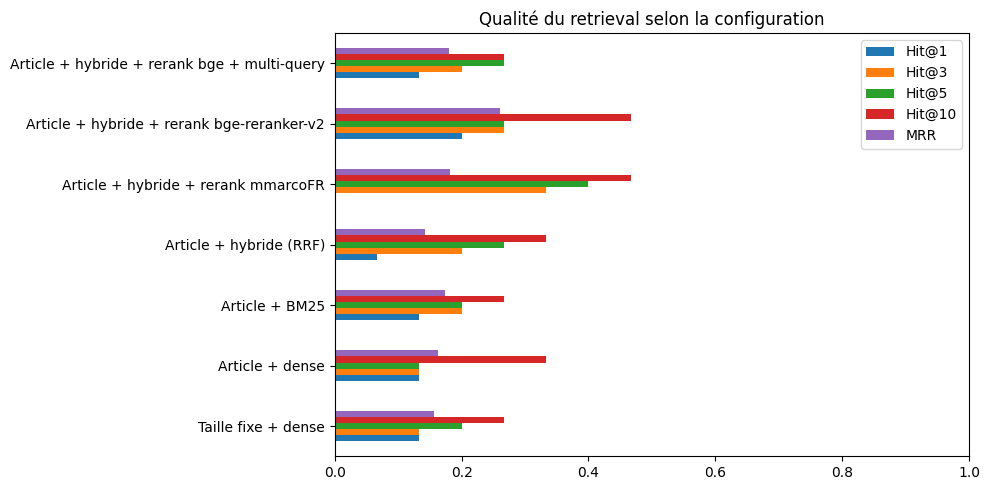

In [20]:
RR_OLD, RR_NEW = CONFIG["CROSS_ENCODER_BASELINE"], CONFIG["CROSS_ENCODER_MODEL"]
RUN_MULTIQUERY = True      # ← False si votre quota LLM est épuisé (la ligne multi-query sera ignorée)
CONFIGS = [
    ("Taille fixe + dense",                         idx_fixed,   "dense",         False, None),
    ("Article + dense",                             idx_article, "dense",         False, None),
    ("Article + BM25",                              idx_article, "bm25",          False, None),
    ("Article + hybride (RRF)",                     idx_article, "hybrid",        False, None),
    ("Article + hybride + rerank mmarcoFR",         idx_article, "hybrid_rerank", False, RR_OLD),
    ("Article + hybride + rerank bge-reranker-v2",  idx_article, "hybrid_rerank", False, RR_NEW),
]
if RUN_MULTIQUERY:
    CONFIGS.append(("Article + hybride + rerank bge + multi-query", idx_article, "hybrid_rerank", True, RR_NEW))
results, all_ranks = {}, {}
for name, index, mode, mq, rr in CONFIGS:
    try:
        results[name], all_ranks[name] = eval_retrieval(index, mode, mq, rr)
    except QuotaExceeded as e:
        print("⚠ Quota épuisé, configuration ignorée :", name, "|", str(e)[:120])
res_df = pd.DataFrame(results).T.round(3)
display(res_df)
res_df[["Hit@1", "Hit@3", "Hit@5", "Hit@10", "MRR"]].plot(kind="barh", figsize=(10, 5))
plt.title("Qualité du retrieval selon la configuration"); plt.xlim(0, 1); plt.tight_layout(); plt.show()

###  Interprétation des Résultats du Retrieval

####  Impact de la réparation du texte et du contexte de chapitre
* La configuration **Article + dense** obtient un **Hit@10 de 0,333** et un **MRR de 0,163**, ce qui reste extrêmement proche de la stratégie **Taille fixe + dense** (**Hit@10 de 0,267**, **MRR de 0,157**).
* L'ajout du contexte hiérarchique de chapitre et le nettoyage du texte n'ont pas provoqué de saut qualitatif spectaculaire sur le retrieval purement dense. Cela s'explique par le fait qu'avec un corpus de petite taille évalué sur seulement **15 questions**, des écarts de quelques points ou de quelques dixièmes sur le MRR ne sont statistiquement pas significatifs et entrent dans la marge de fluttuations attendue.

####  Évaluation du Re-ranking vs Pool Hybride
* **Le meilleur re-ranker** est incontestablement **bge-reranker-v2**, qui domine toutes les métriques avec le score le plus élevé de l'expérimentation, affichant un **Hit@1 de 0,200**, un **Hit@10 de 0,467** et un **MRR maximal de 0,261**.
* **Comparaison avec le pool hybride seul** : L'étape de re-ranking apporte une nette amélioration. La stratégie **Article + hybride (RRF)** seule culmine à un **MRR de 0,142**. L'introduction d'un modèle de re-ranking permet d'augmenter le MRR à **0,181** avec *mmarcoFR* et de le propulser à **0,261** avec *bge-reranker-v2*. Le re-ranking s'avère donc indispensable pour replacer les articles les plus pertinents au sommet de la liste (Top-1 et Top-3).

####  Impact de la stratégie Multi-Query
* La combinaison **Article + hybride + rerank bge + multi-query** dégrade les performances globales par rapport à la même architecture sans multi-query. Le MRR s'effondre à **0,167** et le Hit@10 chute lourdement à **0,200** (contre 0,467 auparavant).
* La réécriture automatique des questions par LLM (Multi-Query) a introduit du bruit ou a trop éloigné les requêtes du vocabulaire très strict et standardisé des lois béninoises, pénalisant fortement la pertinence de la recherche documentaire.

**Choix de la configuration retenue.** La cellule suivante fixe le mode par défaut du pipeline (utilisé ensuite par la calibration, la génération, l'application et le CLI) sur la configuration au meilleur MRR parmi celles que le pipeline sait servir. Justifiez-le en une phrase après lecture du tableau.

In [21]:
serveable = {n: (m, rr, mq) for n, _, m, mq, rr in CONFIGS if n in results}
best_name = res_df.loc[[n for n in res_df.index if n in serveable], "MRR"].idxmax()
mode, reranker, _mq = serveable[best_name]
CONFIG["DEFAULT_MODE"] = mode
if reranker:
    CONFIG["CROSS_ENCODER_MODEL"] = reranker
print("Configuration retenue :", best_name, "→ mode =", mode, "| re-ranker =", reranker)
print("⚠ Si un mode sans re-ranking est retenu, il n'y a pas de score de pertinence : le refus automatique (seuil) est alors inactif.")

Configuration retenue : Article + hybride + rerank bge-reranker-v2 → mode = hybrid_rerank | re-ranker = BAAI/bge-reranker-v2-m3
⚠ Si un mode sans re-ranking est retenu, il n'y a pas de score de pertinence : le refus automatique (seuil) est alors inactif.


### 11.2 Calibration du seuil de pertinence (document grading)
Le score du cross-encoder du meilleur extrait doit être **élevé pour les questions couvertes** et **bas pour les questions hors sujet**. On compare les deux distributions et on choisit le seuil maximisant l'**exactitude équilibrée** (moyenne du taux de questions couvertes acceptées et du taux de hors sujet refusés) ; en cas d'égalité, le plus bas (on préfère répondre à refuser à tort). **Attention** : seuil calibré sur un petit jeu qui sert aussi à l'évaluation → optimiste ; à signaler dans les limites.

Scores top-1 questions couvertes : [0.506, 0.962, 0.892, 0.542, 0.854, 0.999, 0.086, 0.991, 0.897, 0.898, 0.991, 0.116, 0.929, 0.007, 0.952]
Scores top-1 hors sujet          : [0.002, 0.0, 0.001]
Seuil retenu : 0.004 (exactitude équilibrée = 1.00)


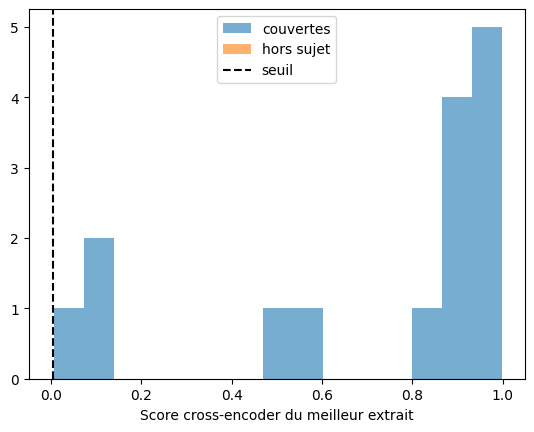

In [22]:
def top_score(q):
    hits = retrieve(idx_article, q["question"], "hybrid_rerank", k=1)
    return hits[0][1] if hits else 0.0

def suggest_threshold(s_in, s_off):
    pts = sorted(set(s_in + s_off))
    cands = [pts[0] - 1e-6] + [(a + b) / 2 for a, b in zip(pts, pts[1:])] + [pts[-1] + 1e-6]
    best = None
    for t in cands:
        ba = (sum(s >= t for s in s_in) / len(s_in) + sum(s < t for s in s_off) / len(s_off)) / 2
        if best is None or ba > best[0] + 1e-12:
            best = (ba, t)
    return best

s_in = [top_score(q) for q in in_scope]
s_off = [top_score(q) for q in off_topic]
print("Scores top-1 questions couvertes :", [round(s, 3) for s in s_in])
print("Scores top-1 hors sujet          :", [round(s, 3) for s in s_off])
ba, thr = suggest_threshold(s_in, s_off)
CONFIG["RERANK_THRESHOLD"] = round(thr, 3)
print(f"Seuil retenu : {CONFIG['RERANK_THRESHOLD']} (exactitude équilibrée = {ba:.2f})")
plt.hist(s_in, alpha=.6, label="couvertes", bins=15); plt.hist(s_off, alpha=.6, label="hors sujet", bins=15)
plt.axvline(CONFIG["RERANK_THRESHOLD"], color="k", ls="--", label="seuil"); plt.legend()
plt.xlabel("Score cross-encoder du meilleur extrait"); plt.show()

In [23]:
def refused(q):   # aucune génération : seulement retrieval + seuil
    return not select_sources(idx_article, q["question"], multiquery=False)[1]
refus_ok = sum(refused(q) for q in off_topic)
faux_refus = sum(refused(q) for q in in_scope)
print(f"Refus corrects (hors sujet) : {refus_ok}/{len(off_topic)}")
print(f"Faux refus (questions couvertes) : {faux_refus}/{len(in_scope)}")

Refus corrects (hors sujet) : 3/3
Faux refus (questions couvertes) : 0/15


### 11.3 Qualité de la génération
Trois critères, sur les questions couvertes : **fidélité** (rien d'absent des extraits), **exactitude des citations** (les articles cités existent dans les extraits fournis et disent bien ce qui est affirmé), **utilité**. On exporte un fichier à **annoter à la main** (référence, fiable) ; un **juge LLM** optionnel n'est qu'un complément indicatif (un LLM évaluant un LLM partage ses biais).

In [24]:
LLM_LOG.clear()
gen, gen_raw = [], []
for q in in_scope:
    r = answer(idx_article, q["question"])
    if r["error"]:
        print(f"⚠ Arrêt à la question {q['id']} ({len(gen)} réponses obtenues) :", r["error"][:250]); break
    gen_raw.append(r)
    cited = set(re.findall(r"Article\s+(\d+\w*)", r["answer"]))
    provided = {str(s["article"]) for s in r["sources"]}
    gen.append({"id": q["id"], "question": q["question"], "answer": r["answer"], "refused": r["refused"],
                "articles_cites": sorted(cited), "articles_fournis": sorted(provided),
                "citations_hors_contexte": sorted(cited - provided), "latency_s": round(r["latency_s"], 2),
                "fidelite_0_1": "", "citations_correctes_0_1": "", "commentaire": ""})
gen_df = pd.DataFrame(gen)
gen_df.to_csv("generation_review.csv", index=False, encoding="utf-8-sig")
print(len(gen_df), "réponses |", int(gen_df["refused"].sum()), "refus automatiques")
print("Réponses citant un article NON fourni dans le contexte :",
      int((gen_df["citations_hors_contexte"].str.len() > 0).sum()), "/", len(gen_df))
gen_df[["id", "question", "refused", "articles_cites", "citations_hors_contexte", "latency_s"]]

15 réponses | 0 refus automatiques
Réponses citant un article NON fourni dans le contexte : 0 / 15


,id,question,refused,articles_cites,citations_hors_contexte,latency_s
0,1,Quelqu'un a publié ma photo sur Facebook sans ...,False,"[574, 576, 608, 610]",[],1.94
1,2,Est-il légal de filmer une personne dans un li...,False,"[574, 608]",[],3.85
2,3,Que risque une personne qui diffuse des images...,False,"[574, 576, 608, 610]",[],4.46
3,4,Une entreprise peut-elle collecter mes données...,False,"[307, 415, 416, 517]",[],4.38
4,5,Comment puis-je demander l'accès à mes données...,False,"[437, 441, 456, 460]",[],4.62
5,6,Quelle autorité est chargée de la protection d...,False,"[1, 462, 483]",[],3.71
6,7,Que risque-t-on pour une injure ou une diffama...,False,"[551, 558]",[],3.88
7,8,Quelle est la sanction du harcèlement par mess...,False,[550],[],4.30
8,9,Est-ce puni de pirater le compte email de quel...,False,"[507, 670]",[],5.03
9,10,Que dit la loi sur l'usurpation d'identité en ...,False,[562],[],3.74


 Taux d'hallucination = 1 − fidélité moyenne.

 Uploade : Le fichier generation_review.csv après remplissage fidelite_0_1 et citations_correctes_0_1

In [26]:

rev = pd.read_csv("generation_review_1.csv")

for col in ["fidelite_0_1", "citations_correctes_0_1"]:
    rev[col] = pd.to_numeric(rev[col], errors="coerce")
print("Réponses annotées :", int(rev["fidelite_0_1"].notna().sum()), "/", len(rev))
print("Fidélité moyenne :", rev["fidelite_0_1"].mean())
print("Citations correctes :", rev["citations_correctes_0_1"].mean())

Réponses annotées : 15 / 15
Fidélité moyenne : 0.9666666666666667
Citations correctes : 0.9666666666666667


In [27]:
# (Complément indicatif) juge LLM de la fidélité — désactivé par défaut pour économiser le quota
def llm_judge(question, answer_text, sources):
    ctx = "\n---\n".join(s["text"] for s in sources)
    p = (f"CONTEXTE:\n{ctx}\n\nRÉPONSE À ÉVALUER:\n{answer_text}\n\n"
         "La réponse contient-elle une affirmation juridique NON soutenue par le contexte ? Réponds par un seul mot : FIDELE ou INFIDELE.")
    return call_llm(p, kind="judge", temperature=0.0, max_tokens=64).strip().upper()
RUN_JUDGE = False   # ← True seulement si votre quota le permet (1 appel LLM par réponse jugée)
if RUN_JUDGE:
    judged = [llm_judge(q["question"], g["answer"], r["sources"])
              for q, g, r in zip(in_scope[:8], gen[:8], gen_raw[:8])]
    print(judged)

### 11.4 Latence, coût et robustesse (métriques d'intégration)

In [28]:
log = pd.DataFrame(LLM_LOG)
if len(log):
    cols = [c for c in ["latency_s", "tokens_in", "tokens_out"] if c in log]
    print(log.groupby("kind")[cols].agg(["mean", "max"]).round(2))
    print("Modèles utilisés :", log["model"].value_counts().to_dict() if "model" in log else "n/a")
    print("Réponses servies depuis le cache :", int(log["cached"].sum()), "/", len(log), "(latences = mesures d'origine)")
    print("Appels ayant nécessité un retry :", int((log["attempt"] > 1).sum()), "/", len(log))
if len(gen_df):
    print("Latence de bout en bout (s) — moyenne / médiane / max :",
          round(gen_df["latency_s"].mean(), 1), round(gen_df["latency_s"].median(), 1), gen_df["latency_s"].max())
# Coût estimé : renseignez les tarifs OFFICIELS actuels de votre modèle (USD par million de tokens)
PRICE_IN, PRICE_OUT = None, None
if PRICE_IN is not None and len(log):
    cost = (log["tokens_in"].sum() * PRICE_IN + log["tokens_out"].sum() * PRICE_OUT) / 1e6
    print(f"Coût total du jeu de test : {cost:.4f} USD | par question : {cost / len(in_scope):.5f} USD")
backup_to_drive()

                latency_s       tokens_in       tokens_out     
                     mean   max      mean   max       mean  max
kind                                                           
generation           2.27  3.33   1424.33  1960     545.73  908
query_expansion      1.20  1.67    164.93   173     119.27  150
Modèles utilisés : {'gemini-flash-lite-latest': 30}
Réponses servies depuis le cache : 16 / 30 (latences = mesures d'origine)
Appels ayant nécessité un retry : 0 / 30
Latence de bout en bout (s) — moyenne / médiane / max : 4.1 4.1 5.32
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sauvegarde effectuée sur Drive.


## 12. Analyse : succès, échecs, limites, pistes d'amélioration


In [29]:
best_hits_name = "Article + hybride + rerank bge-reranker-v2"
if best_hits_name in all_ranks:
    for q, rank in zip(in_scope, all_ranks[best_hits_name]):
        if rank is None or rank > 3:
            print(f"[#{q['id']}] rang={rank} | {q['question']}\n     attendu : {q['expected']}")

[#1] rang=None | Quelqu'un a publié ma photo sur Facebook sans mon accord. Que dit la loi ?
     attendu : ['CODE-DU-NUMERIQUE::33', 'CODE-DU-NUMERIQUE::550']
[#2] rang=None | Est-il légal de filmer une personne dans un lieu privé sans son consentement et de diffuser la vidéo ?
     attendu : ['CODE-DU-NUMERIQUE::12', 'CODE-DU-NUMERIQUE::550']
[#3] rang=None | Que risque une personne qui diffuse des images intimes d'une autre personne sans son accord ?
     attendu : ['CODE-DU-NUMERIQUE::550']
[#4] rang=None | Une entreprise peut-elle collecter mes données personnelles sans m'en informer ?
     attendu : ['CODE-DU-NUMERIQUE::1']
[#5] rang=9 | Comment puis-je demander l'accès à mes données personnelles ou leur suppression ?
     attendu : ['CODE-DU-NUMERIQUE::1', 'CODE-DU-NUMERIQUE::33']
[#7] rang=None | Que risque-t-on pour une injure ou une diffamation publiée sur les réseaux sociaux ?
     attendu : ['CODE-DU-NUMERIQUE::550', 'CODE-DU-NUMERIQUE::562']
[#9] rang=None | Est-ce puni de 

**Limites (à adapter, elles sont réelles) :**
- Le système ne couvre que les textes de `corpus/` : une loi absente, abrogée ou modifiée (ex. **loi n° 2020-35** modifiant le Code du numérique) entraîne une réponse incomplète ou périmée. Le corpus doit être tenu à jour.
- Les PDF contiennent des **coquilles** (ex. un montant écrit « cent mille (500.000) » dans le Code pénal) et certains ont une extraction de texte défectueuse ; la réparation appliquée est heuristique. Le système doit citer les montants tels qu'écrits.
- Jeu d'évaluation petit, annoté par l'équipe, et seuil calibré sur ce même jeu : conclusions statistiques fragiles.
- Information générale, **pas un avis juridique** : le système ignore les faits, la jurisprudence et la procédure ; l'applicabilité d'un article dépend des circonstances.
- Dépendance à une API externe (quotas, modèles retirés) : atténuée par le cache et les modèles de secours, pas supprimée.

**Pistes d'amélioration :** ajouter la loi 2020-35 et les décrets d'application ; OCR / copies propres des textes ; détection des versions et des abrogations ; jeu d'évaluation plus grand validé par un juriste ; fine-tuning de l'embedding sur le vocabulaire juridique béninois ; interface en langues nationales.

## 13. Éthique et intégrité
- **Vie privée** : les textes de loi sont publics ; les questions des utilisateurs sont envoyées à l'API Gemini, il faut donc demander de ne pas y saisir de données personnelles sensibles.
- **Non-nuisance** : avertissement systématique, refus d'inventer, citations vérifiables ; l'outil ne doit pas servir à intimider ni à remplacer un professionnel du droit.
- **Sources et licences** : tous les textes utilisés sont cités (voir README) ; modèles tiers utilisés selon leurs licences (bge-m3, bge-reranker-v2-m3, mmarcoFR, Gemini).
- **Transparence** : limites documentées ; les résultats présentés sont ceux obtenus par l'exécution de ce notebook, y compris l'itération 1 qui a révélé ses défauts.